# Analysis code for HREX simulations

## Compute the FES in the polar system from unscaled replica 

In [3]:
import MDAnalysis as mda
import numpy as np
from MDAnalysis.analysis import align
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns

In [1]:
# meta_cluster is the PBC corrected trajectory
u = mda.Universe('ref.pdb', 'meta_cluter.xtc')
reference = mda.Universe('../ref_bb.pdb')
reference_frame = reference.select_atoms('backbone').positions.copy()
reference_all=reference.select_atoms('all')

NameError: name 'mda' is not defined

In [5]:
align.AlignTraj(u, reference, select='backbone', in_memory=True).run()

In [6]:
def get_normal_vector(coords):
    geometric_center = np.mean(coords, axis=0)
    traslated_coords = coords - geometric_center
    N = len(coords)
    R_prime = np.zeros(3)
    R_double_prime = np.zeros(3)
    for j in range(N):
        R_prime += traslated_coords[j] * np.cos(2 * np.pi * j / N)
        R_double_prime += traslated_coords[j] * np.sin(2 * np.pi * j / N)
    normal_vector = np.cross(R_prime, R_double_prime)
    normal_vector /= np.linalg.norm(normal_vector)  
    return normal_vector

In [2]:
normal_vectors=[]
for ts in u.trajectory:
    ring=u.select_atoms('id 1978 1968 1971 1973 1975 1977') # these are the indices of the sugar ring atoms 
    coords=ring.positions
    normal_vectors.append(get_normal_vector(coords))

NameError: name 'u' is not defined

In [8]:
np.savetxt('normal_vectors.txt', normal_vectors, header='Nx Ny Nz', comments='#')

In [9]:
normal_vectors=np.loadtxt('normal_vectors.txt')
normal_vectors

array([[-0.45229073, -0.22229027,  0.86372457],
       [-0.3709867 , -0.35446132,  0.85832747],
       [ 0.32667181, -0.92801292, -0.17910207],
       ...,
       [-0.59701118, -0.67724759, -0.43001553],
       [ 0.16869738,  0.43777959, -0.88311394],
       [-0.73983656,  0.26016494, -0.62044828]])

In [10]:
ca_atoms=reference.select_atoms('name CA')

In [11]:
projections=[]
for i in range(len(normal_vectors)):
    projections.append(np.dot(ca_atoms.principal_axes(), normal_vectors[i]))
projections=np.array(projections)

In [12]:
def cartesian_to_spherical(cartesian_coords):
    x, y, z = cartesian_coords
    r = np.linalg.norm(cartesian_coords)  
    phi = np.degrees(np.arctan2(y, x))  
    theta = np.degrees(np.arccos(z / r)) 
    return (phi, theta, r)

In [13]:
polar=[]
for i in projections:
    polar.append(cartesian_to_spherical(i))

polar=np.array(polar).transpose()
phi, theta, r = polar

In [14]:
cv = np.loadtxt('DIST')[:,1]

In [15]:
polar_system = np.loadtxt('polar_data.txt')

In [16]:
df = pd.DataFrame(polar_system, columns=['CV', 'phi', 'theta'])

In [17]:
df.to_csv('fes_polar_system.csv', index=False, encoding='utf-8')

## Compute the FES from all replicas in 3D space 

In [70]:
colvar=np.loadtxt('COLVAR').transpose()

In [72]:
energies=[]
for i in range(18):
    # denergy is the energy file from the demuxed trajectory 
    bb=np.loadtxt(f"denergy_{i}.xvg",usecols=1) + colvar[6] + colvar[7] + colvar[9] + colvar[11] 
    energies.append(bb)
energies=np.array(energies).T

In [16]:
np.savetxt('bias.txt', energies, comments='' )

In [73]:
kBT=0.00831446261815324*300
w=wham.wham(energies,T=kBT) # the wham function taken from plumed python script
logW=w["logW"]-energies[:,-1]/kBT
logW-=np.max(logW) 
weights=np.exp(logW)
weights/=np.sum(weights) 
w['logW']=list(w['logW'])
w['logZ']=list(w['logZ'])

In [75]:
np.savetxt('logws.txt', logW, comments='' )

In [ ]:
np.savetxt('weights.txt', weights, comments='' )

In [78]:
data = np.loadtxt('polar_data.txt')

In [80]:
with open(f"data.dat", 'w') as f:
    f.write('#! FIELDS time d phi theta logw\n')
    for j in range(data.shape[0]):
        f.write(f"{j} {data[:,0][j]} {data[:,1][j]} {data[:,2][j]} {logW[j]}\n")

In [81]:
!plumed driver --plumed plumed.dat --noatoms

PLUMED: PLUMED is starting
PLUMED: Version: 2.8.3 (git: Unknown) compiled on Apr 22 2024 at 13:20:35
PLUMED: Please cite these papers when using PLUMED [1][2]
PLUMED: For further information see the PLUMED web page at http://www.plumed.org
PLUMED: Root: /home/davidelu/plumed/lib/plumed
PLUMED: For installed feature, see /home/davidelu/plumed/lib/plumed/src/config/config.txt
PLUMED: Molecular dynamics engine: driver
PLUMED: Precision of reals: 8
PLUMED: Running over 1 node
PLUMED: Number of threads: 1
PLUMED: Cache line size: 512
PLUMED: Number of atoms: 0
PLUMED: File suffix: 
PLUMED: FILE: plumed.dat
PLUMED: Action READ
PLUMED:   with label phi
PLUMED:   with stride 1
PLUMED:   reading data from file data.dat
PLUMED:   reading value phi and storing as phi
PLUMED: Action READ
PLUMED:   with label theta
PLUMED:   with stride 1
PLUMED:   reading data from file data.dat
PLUMED:   reading value theta and storing as theta
PLUMED: Action READ
PLUMED:   with label d
PLUMED:   with stride 1
PL

## Algorithm to optimize the lambda ladder

In [ ]:
energies=[]
for i in range(19):
    # energies taken from the trial replica ladder
    energies.append(np.loadtxt(f"energy_{i}.xvg".format(i),usecols=1)) 
energies=np.array(energies).T

In [ ]:
energies.shape

(19019, 19)

In [ ]:
kBT=0.00831446261815324*300
w=wham.wham(energies,T=kBT)
logW=w["logW"]-energies[:,0]/kBT
logW-=np.max(logW)
weights=np.exp(logW)
weights/=np.sum(weights) 
w['logW']=list(w['logW'])
w['logZ']=list(w['logZ'])

In [ ]:
coefficients=[]
for i in range(energies.shape[0]):
    c=np.polyfit(np.sqrt(lam),energies[i],2)
    coefficients.append(c)
coefficients=np.array(coefficients)
residual=np.dot(coefficients, np.array((lam,np.sqrt(lam),np.ones(len(lam)))))-energies

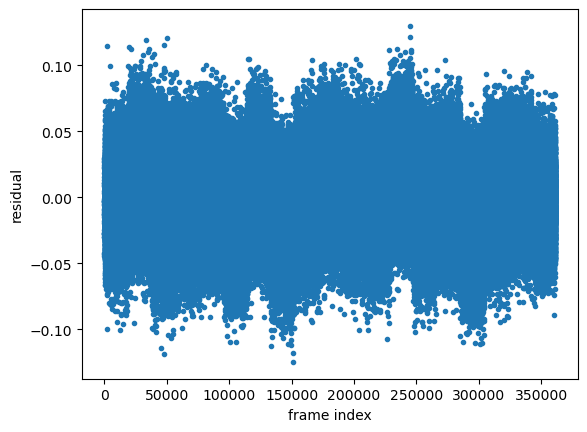

In [ ]:
# This is the residual, very small
plt.plot(residual.T.flatten(),".")
plt.xlabel("frame index")
plt.ylabel("residual")
plt.show()

In [ ]:
def predict_acceptance(l1,l2):
    e1=coefficients[:,0]*l1+coefficients[:,1]*np.sqrt(l1)+coefficients[:,2]
    e2=coefficients[:,0]*l2+coefficients[:,1]*np.sqrt(l2)+coefficients[:,2]
    
    logW1=w["logW"]-e1/kBT
    logW2=w["logW"]-e2/kBT
    logW1-=np.max(logW1)
    logW2-=np.max(logW2)
    w1=np.exp(logW1)
    w2=np.exp(logW2)
    w1/=np.sum(w1)
    w2/=np.sum(w2)
    
    w1=w1[::5]
    w2=w2[::5]
    a=[]
    for i in range(len(w1)):
        if 0 in w1[i]*w2[:]:
            a.append(np.average(np.minimum(w1[:]*w2[i]/(1.00e-300),1.0),weights=w2))
        else:
            a.append(np.average(np.minimum(w1[:]*w2[i]/(w1[i]*w2[:]),1.0),weights=w2))
    return np.average(a,weights=w1)  

In [ ]:
for i in range(len(lam)-1):
    print(predict_acceptance(lam[i],lam[i+1]))

0.23876633292279179
0.26494247794667397
0.2987691861960117
0.32052459905196945
0.3923894908478801
0.37852598440079677
0.4120524338887919
0.41504034864488454
0.4372720883022716
0.4731841703601992
0.48913828904138446
0.4793058665381885
0.4921300053745094
0.5244798918849578
0.5101251854959088
0.5270493189035874
0.5507439699949787
0.563230742057024


In [ ]:
T_new = 1000
t_new = 300
N = 18

x_values = np.linspace(0, N-1, N)

def f_corrected(x, t, T, N):
    return t / (t * np.exp((x * np.log(T / t)) / (N - 1)))

# Calculate distribution values for the new parameters
corrected_distribution_values_new = f_corrected(x_values, t_new, T_new, N)

def f_adjusted_steepness(x, t, T, N, alpha):
    return t / (t * np.exp(alpha * (x * np.log(T / t)) / (N - 1)))

# Steepness factor
alpha = 0.64

# Calculate distribution values for the adjusted function with increased steepness
adjusted_distribution_values_steepness = f_adjusted_steepness(x_values, t_new, T_new, N, alpha)

original_min, original_max = np.min(corrected_distribution_values_new), np.max(corrected_distribution_values_new)

# Calculate the min and max of the adjusted distribution
adjusted_min, adjusted_max = np.min(adjusted_distribution_values_steepness), np.max(adjusted_distribution_values_steepness)

# Scale the adjusted distribution to have the same min and max as the original
scaled_distribution_values_steepness = ((adjusted_distribution_values_steepness - adjusted_min) / (adjusted_max - adjusted_min)) * (original_max - original_min) + original_min

corrected_distribution_values_new.sort()
scaled_distribution_values_steepness.sort()
scaled_distribution_values_steepness=[round(i,3) for i in scaled_distribution_values_steepness]

[0.3, 0.328, 0.357, 0.388, 0.42, 0.453, 0.488, 0.525, 0.564, 0.604, 0.646, 0.69, 0.736, 0.784, 0.834, 0.887, 0.942, 1.0]


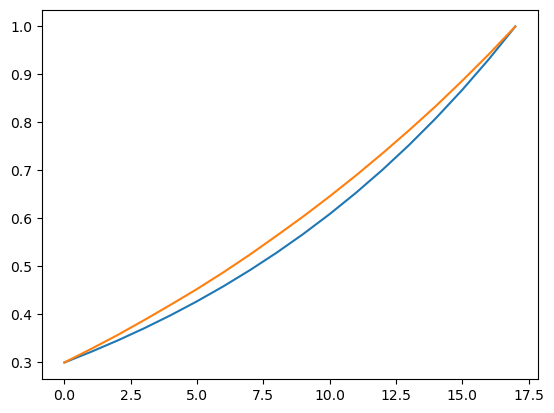

In [ ]:
plt.figure()

plt.plot(corrected_distribution_values_new)
plt.plot(scaled_distribution_values_steepness)
print(scaled_distribution_values_steepness)

In [ ]:
ps=[]
for i in range(len(scaled_distribution_values_steepness)-1):
    ps.append(predict_acceptance(round(scaled_distribution_values_steepness[i],3),round(scaled_distribution_values_steepness[i+1],3)))
ps=np.array(ps)

pgl=[]
for i in range(len(corrected_distribution_values_new)-1):
    pgl.append(predict_acceptance(corrected_distribution_values_new[i],corrected_distribution_values_new[i+1]))
pgl=np.array(pgl)

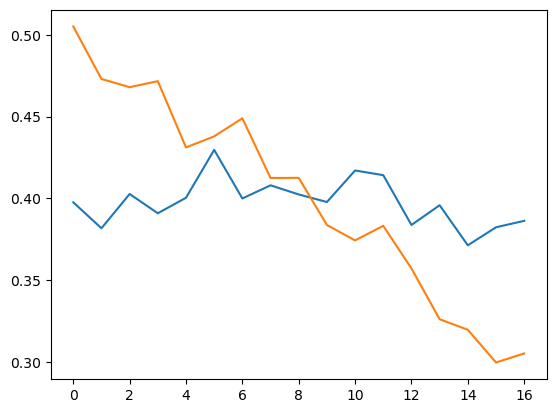

In [ ]:
plt.figure()
plt.plot(ps)
plt.plot(pgl)


## Quality check 

In [18]:
replica_temp=np.loadtxt("replica_temp.xvg")
df = pd.DataFrame(replica_temp[:,1:])
# Get total number of replicas and positions
num_replicas = df.shape[1]
positions = df.values.flatten()
num_posizioni = int(positions.max()) + 1  # Get max position and add 1 to cover all positions 

# Define a matrix with size (replicas x positions)
frequency_matrix = np.zeros((num_replicas, num_posizioni))

# Coumpute the frequency for each replica to be in a specific position
for i in range(num_replicas):
    counts = df.iloc[:, i].value_counts()
    for position, count in counts.items():
        frequency_matrix[i, int(position)] = count

# Normalization to get probability 
probability_matrix = frequency_matrix / frequency_matrix.sum(axis=1, keepdims=True)

In [24]:
np.save("prob_matrix_gap.npy", probability_matrix)

In [9]:
replica_temp=np.loadtxt("replica_temp.xvg")
data = pd.DataFrame(replica_temp)
# Number of replicas excluding time colum 
num_replicas = data.shape[1] - 1
num_timesteps = len(data)

# Array to save mean sqared displacement over time
msd = np.zeros(num_timesteps)

# Compute the mean squared displacement over time 
for t in range(num_timesteps):
    squared_displacements = []
    for replica_id in range(1, num_replicas + 1):  # Start form 1 to excluding time colum 
        # Initial position for the replica 
        initial_position = data.iloc[0, replica_id]
        # Replica position at time t
        current_position = data.iloc[t, replica_id]
        # Compute mean squared displacement 
        squared_displacement = (current_position - initial_position) ** 2
        squared_displacements.append(squared_displacement)
    # Average over replicas 
    msd[t] = np.mean(squared_displacements)

In [10]:
np.save("msd_gap.npy", msd)